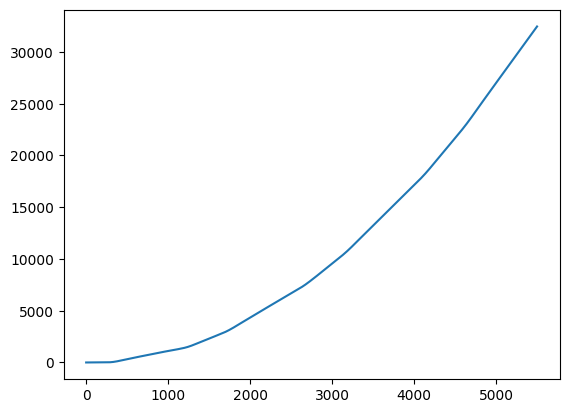

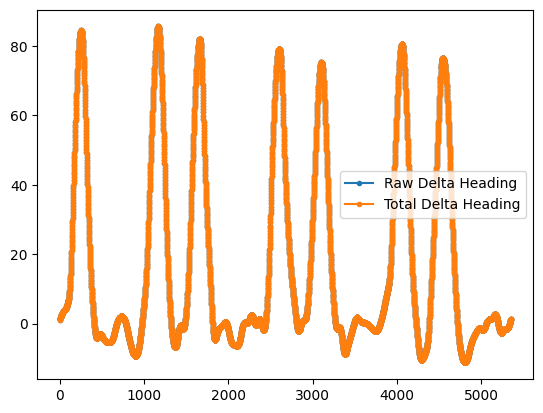

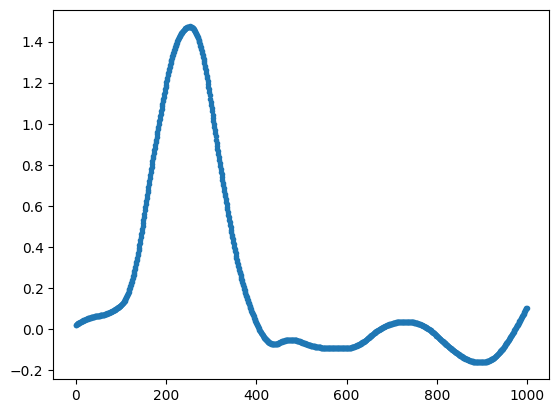

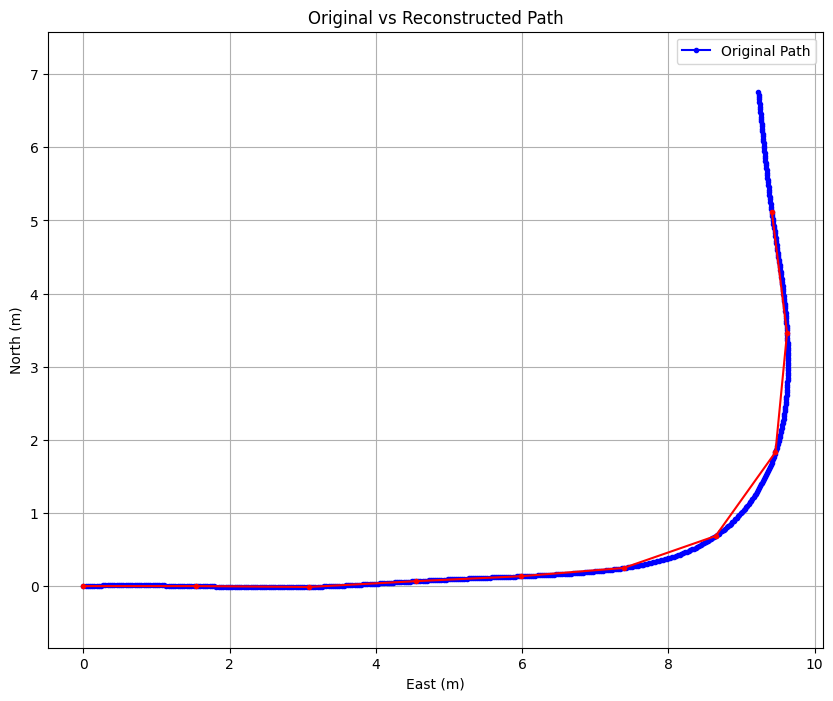

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pyproj import Proj
import math
from scipy.interpolate import interp1d
from scipy.interpolate import interp1d, PchipInterpolator, UnivariateSpline, CubicSpline



def load_and_process_data(file_path, skiprows=500, flag=False, zone=52):
    if flag:
        df = pd.read_csv(
            file_path, skiprows=skiprows, skipfooter=100,
            na_values=['', 'nan', 'NaN'], engine='python'
        ).fillna(0)
    else:
        df = pd.read_csv(
        file_path, skiprows=skiprows, skipfooter=100, engine='python'
        )
        
    df.columns = [
        'Time',
        'Accelerometer x', 'Accelerometer y', 'Accelerometer z',
        'Gyroscope x', 'Gyroscope y', 'Gyroscope z',
        'Magnetometer x', 'Magnetometer y', 'Magnetometer z',
        'Orientation x', 'Orientation y', 'Orientation z',
        'Pressure', 'Latitude', 'Longitude', 'Altitude', 'Speed_GPS'
    ]

    df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S.%f')
    start_dt = df['Time'].iloc[0]
    df['Elapsed Time'] = (df['Time'] - start_dt).dt.total_seconds()
    
    if flag:
        # (기존 원본 로직 그대로 유지)
        valid_gps_mask = (
            df['Latitude'].notna() & df['Longitude'].notna() &
            (df['Latitude'].astype(str).str.strip() != '') &
            (df['Longitude'].astype(str).str.strip() != '')
        )
        valid_lat = pd.to_numeric(df.loc[valid_gps_mask, 'Latitude'], errors='coerce')
        valid_lon = pd.to_numeric(df.loc[valid_gps_mask, 'Longitude'], errors='coerce')
        final_mask = valid_lat.notna() & valid_lon.notna()
        valid_lat = valid_lat[final_mask].values
        valid_lon = valid_lon[final_mask].values
        if len(valid_lat) == 0:
            raise ValueError("유효한 GPS 데이터가 없습니다.")
        proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
        e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
        e_valid, n_valid = proj_enu(valid_lon, valid_lat)
        e_valid -= e0; n_valid -= n0
        df['E'], df['N'] = np.nan, np.nan
        df.loc[valid_gps_mask, 'E'] = e_valid
        df.loc[valid_gps_mask, 'N'] = n_valid
        e = df['E'][df['E'].notna()].values
        n = df['N'][df['N'].notna()].values
    else:
        df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')
        df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
        proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
        e_all, n_all = proj_enu(df['Longitude'].values, df['Latitude'].values)
        e0, n0 = proj_enu(df['Longitude'].iloc[0], df['Latitude'].iloc[0])
        df['E'] = e_all - e0
        df['N'] = n_all - n0
        M = len(df)
        n_sec = M // 50
        e, n = [], []
        for i in range(n_sec):
            idx = min(i*50 + 25, M-1)
            e.append(df['E'].iloc[idx])
            n.append(df['N'].iloc[idx])
        e = np.array(e)
        n = np.array(n)
            
    # ------------------------------------------------------------------
    # 5) 1Hz 궤적 보정: 초기 heading 회전 정렬
    # ------------------------------------------------------------------
    dx0, dy0 = e[1]-e[0], n[1]-n[0]
    theta0 = math.atan2(dy0, dx0)
    R0 = np.array([[math.cos(-theta0), -math.sin(-theta0)],
                    [math.sin(-theta0),  math.cos(-theta0)]])
    coords = np.vstack([e-e[0], n-n[0]])
    rotated = R0 @ coords
    e_corr, n_corr = rotated[0], rotated[1]
    
    # 1) 보간용 원본 인덱스와 타겟 인덱스 생성
    M = len(e_corr)
    t_old = np.arange(M)                          
    t_new = np.linspace(0, M - 1, (M-1)*50 + 1)          

    # 2) 선형 보간 함수 생성
    # f_e = interp1d(t_old, e_corr, kind='CubicSpline')
    # f_n = interp1d(t_old, n_corr, kind='CubicSpline')
    f_e_pchip = CubicSpline(t_old, e_corr)
    f_n_pchip = CubicSpline(t_old, n_corr)
    
    # 3) 50개 포인트로 보간
    e_aug = f_e_pchip(t_new)   # shape = (50,)
    n_aug = f_n_pchip(t_new)   # shape = (50,)
    
    # df['e_aug'] = e_aug
    # df['n_aug'] = n_aug
    
    df2 = df.iloc[:len(e_aug)].copy()

    # 2) 그 위에 보간 결과를 할당
    df2['e_aug'] = e_aug
    df2['n_aug'] = n_aug
    
    e = df2['e_aug'].values  # shape = (T,)
    n = df2['n_aug'].values  # shape = (T,)

    window_size = 150  # 1초 = 50샘플
    num_wins = len(e) - window_size + 1

    
    # 결과 저장용
    y_speed = np.zeros(num_wins)
    y_dh    = np.zeros(num_wins)
    
    delta_head = np.arctan2(
        np.diff(n_aug), np.diff(e_aug)
    )
    cum_head = np.cumsum(np.unwrap(delta_head))
    plt.plot(cum_head)
    plt.show()
    
    temp = []

    for i in range(num_wins):
        we = e[i : i+window_size]   # window of Eastings
        wn = n[i : i+window_size]   # window of Northings

        # 1) 속도: 시작점→종료점 직선 이동 거리 (m/s)
        dx = we[-1] - we[0]
        dy = wn[-1] - wn[0]
        dist = np.hypot(dx, dy)    # sqrt(dx^2 + dy^2)
        y_speed[i] = dist          # 1초 동안 이동거리 = 속도(m/s)

        # 2) 방향변화량: 각 샘플 간 heading 변화를 누적
        
        headings = np.arctan2(np.diff(wn), np.diff(we))
        headings = np.unwrap(headings)

        # Δheading 원본
        raw_delta = headings[-1] - headings[0]
        temp.append(raw_delta)
        
        # 윈도우 내 실질적인 회전량 (sum of abs)
        dh = np.diff(headings)
        total_delta = np.sum(dh)

        # # 소프트 데드존 적용
        # if abs(raw_delta) < threshold:
        #     delta = 0
        # else:
        #     delta = np.sign(raw_delta) * (abs(raw_delta) - threshold)

        y_dh[i] = total_delta
        
    plt.plot(np.degrees(temp), '.-', label='Raw Delta Heading')
    plt.plot(np.degrees(y_dh), '.-', label='Total Delta Heading')
    plt.legend()
    plt.show()
        
    sensor_cols = ['Accelerometer x','Accelerometer y','Accelerometer z',
            'Gyroscope x','Gyroscope y','Gyroscope z']
    sensor = df2[sensor_cols].values  # shape = (T,6)

    X = np.zeros((num_wins, window_size, 6))
    for i in range(num_wins):
        X[i] = sensor[i : i+window_size]

    # (2) Y 결합
    Y = np.vstack([y_speed, y_dh]).T   # shape = (num_wins, 2)
    
    plt.plot(y_dh[:1000], '.-')
    plt.show()
    
    # Initialize arrays for reconstructed path
    path_e = np.zeros(len(y_speed))
    path_n = np.zeros(len(y_speed))
    current_heading = 0

    # Reconstruct path from speed and heading changes
    for i in range(len(y_speed)):
        # Update heading
        current_heading += (y_dh[i] * 0.02)
        
        # Calculate displacement using speed and heading
        dx = (y_speed[i]*0.02) * np.cos(current_heading)
        dy = (y_speed[i]*0.02) * np.sin(current_heading)
        
        # Update position
        if i > 0:
            path_e[i] = path_e[i-1] + dx
            path_n[i] = path_n[i-1] + dy

    # Plot original and reconstructed paths
    plt.figure(figsize=(10, 8))
    plt.plot(e[:500], n[:500], 'b.-', label='Original Path')
    plt.plot(e_corr[:10], n_corr[:10], 'r.-')
    #plt.plot(path_e, path_n, 'r.-', label='Reconstructed Path')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.xlabel('East (m)')
    plt.ylabel('North (m)')
    plt.title('Original vs Reconstructed Path')
    plt.show()

        
    return df2, X, Y

path1 = 'data/learn_data/Basket_1.csv'

df1, X, Y = load_and_process_data(path1, skiprows=300, flag=False, zone=52)